In [ ]:
- from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shahdwalied","key":"26d1098abbb2bbe431c774fa95b53339"}'}

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 156MB/s]



In [ ]:
import zipfile

zip_path = "/content/chest-xray-pneumonia.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_dir = "/content/chest_xray/train"
val_dir = "/content/chest_xray/val"
test_dir = "/content/chest_xray/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 157s 787ms/step - accuracy: 0.8501 - loss: 0.3431 - val_accuracy: 0.8125 - val_loss: 0.4401
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 683ms/step - accuracy: 0.9352 - loss: 0.1859 - val_accuracy: 0.8125 - val_loss: 0.3816
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 680ms/step - accuracy: 0.9383 - loss: 0.1636 - val_accuracy: 0.8750 - val_loss: 0.3766
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9431 - loss: 0.1511 - val_accuracy: 0.8750 - val_loss: 0.3372
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.9494 - loss: 0.1377 - val_accuracy: 0.8125 - val_loss: 0.2882
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 672ms/step - accuracy: 0.9528 - loss: 0.1304 - val_accuracy: 0.8750 - val_loss: 0.3621
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 686ms/step - accuracy: 0.9521 - loss: 0.1269 - val_accuracy: 0.8125 - val_loss: 0.2642
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 681ms/step - accuracy: 0.9538 -

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.8766 - loss: 0.3085
Test Accuracy: 0.8766025900840759


Improved Preprocessing/
Data Augmentation

In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input

# تحسين الـ Augmentation لصور الأشعة
train_datagen_improved = ImageDataGenerator(
    preprocessing_function=preprocess_input, # مهم جداً لـ DenseNet
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    shear_range=0.15,
    brightness_range=[0.7, 1.3], # تعامل مع اختلاف إضاءة الأشعة
    fill_mode='nearest'
)

val_test_datagen_improved = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

New Generators


In [ ]:
train_generator_ft = train_datagen_improved.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary'
)

val_generator_ft = val_test_datagen_improved.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary'
)

test_generator_ft = val_test_datagen_improved.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Load Model Again + Fine-Tuning

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze الأول
for layer in base_model.layers:
    layer.trainable = False

# فك آخر layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)  #  Regularization
output = Dense(1, activation='sigmoid')(x)

model_ft = Model(inputs=base_model.input, outputs=output)

model_ft.compile(
    optimizer=Adam(learning_rate=1e-5),  # قللنا learning rate عشان fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

Train Fine-Tuned Model

In [ ]:
history_ft = model_ft.fit(
    train_generator_ft,
    validation_data=val_generator_ft,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 826ms/step - accuracy: 0.7880 - loss: 0.4407 - val_accuracy: 0.5000 - val_loss: 0.6024 - learning_rate: 1.0000e-05
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 736ms/step - accuracy: 0.8645 - loss: 0.3198 - val_accuracy: 0.7500 - val_loss: 0.4986 - learning_rate: 1.0000e-05
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 727ms/step - accuracy: 0.8857 - loss: 0.2697 - val_accuracy: 0.8750 - val_loss: 0.4296 - learning_rate: 1.0000e-05
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 726ms/step - accuracy: 0.9059 - loss: 0.2341 - val_accuracy: 0.8750 - val_loss: 0.3741 - learning_rate: 1.0000e-05
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 722ms/step - accuracy: 0.9133 - loss: 0.2204 - val_accuracy: 0.8750 - val_loss: 0.3388 - learning_rate: 1.0000e-05
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 723ms/step - accuracy: 0.9252 - loss: 0.1894 - val_accuracy: 0.8750 - val_loss: 0.3079 - learning_rate: 1.0000e-05
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 

Evaluate

In [ ]:
test_loss_ft, test_acc_ft = model_ft.evaluate(test_generator_ft)
print("Fine-Tuned Test Accuracy:", test_acc_ft)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - accuracy: 0.9022 - loss: 0.2412
Fine-Tuned Test Accuracy: 0.9022436141967773


Comparison

Overfitting Analysis

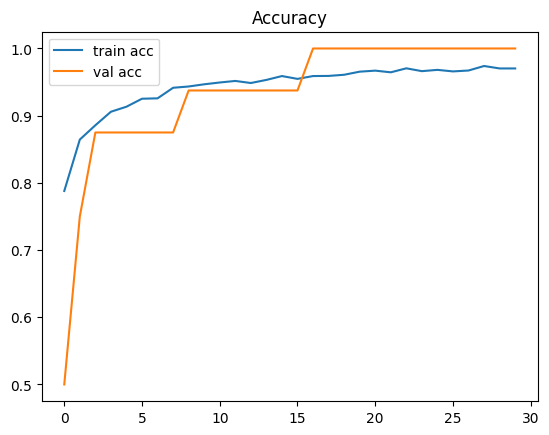

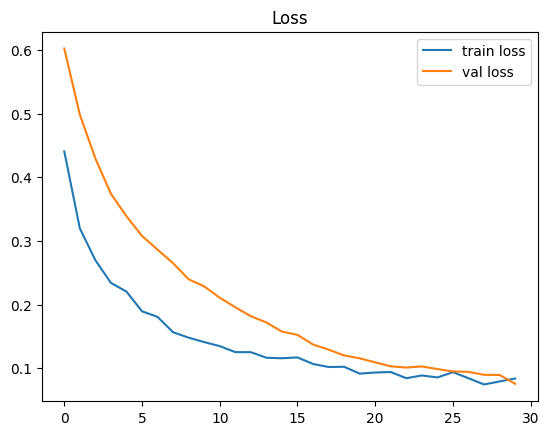

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_ft.history['accuracy'], label='train acc')
plt.plot(history_ft.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history_ft.history['loss'], label='train loss')
plt.plot(history_ft.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()